# Finer-Grad-CAM: Fine-Grained Gradient-Based Visual Explanations with Contrastive Localization

**Author:** Mehdy Mokhtari  
**Date:** 23 May 2026  
**Reference Paper:** *Finer-CAM : Spotting the Difference Reveals Finer Details for Visual Explanation* 

---

### Project Overview

This project implements **Finer-Grad-CAM**, an extension of Grad-CAM that enables **contrastive visual explanations** by comparing a **target class** against one or more **reference (similar) classes**. Unlike standard Grad-CAM, which highlights regions supporting a single class, Finer-Grad-CAM isolates discriminative features that **distinguish** the target class from similar classes, producing finer and more focused saliency maps.

---

### Key Technical Concepts

| Concept | Description |
|---------|-------------|
| **Finer-Grad-CAM** | Extends Grad-CAM by incorporating a contrastive mechanism between target and reference classes |
| **Contrastive Localization** | Highlights regions where the target class differs from reference classes, suppressing shared features |
| **Balance Factor (λ)** | Hyperparameter controlling the influence of reference class gradients relative to the target class |
| **Reference Classes** | One or more classes similar to the target (e.g., different bird species, cat breeds) to enhance fine-grained discrimination |
| **Class-discriminative** | Produces different heatmaps for different target-reference pairs |

---

### Mathematical Foundation

**Standard Grad-CAM weights for target class c:**

$$
\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}
$$

**Finer-Grad-CAM weights (with reference class r):**

$$
\alpha_k^{c,r} = \frac{1}{Z} \sum_i \sum_j \left( \frac{\partial y^c}{\partial A_{ij}^k} - \lambda \cdot \frac{\partial y^r}{\partial A_{ij}^k} \right)
$$

**Finer-Grad-CAM heatmap:**

$$
L_{Finer}^{c,r} = \text{ReLU}\left( \sum_k \alpha_k^{c,r} A^k \right)
$$

Where:
- \( c \) = target class
- \( r \) = reference class (e.g., similar species/breed)
- \( \lambda \) = balance factor (typically 0.5–1.0)

**Key property:** When \( \lambda = 0 \), Finer-Grad-CAM reduces to standard Grad-CAM. When \( \lambda > 0 \), it suppresses features shared with the reference class, highlighting only discriminative regions.

---

### Implementation Scope

| Component | Implementation |
|-----------|----------------|
| **Model** | ResNet-18 pre-trained on ImageNet-1k |
| **Dataset** | Tiny ImageNet / ImageNet subset |
| **Target Classes** | Fine-grained categories (e.g., Persian Cat vs. Tiger Cat) |
| **Reference Classes** | Similar classes to enable contrastive explanation |
| **Visualization** | Finer-Grad-CAM heatmaps + comparison with standard Grad-CAM |

---

### Technologies Used

- **PyTorch** – Automatic differentiation for gradient computation
- **Torchvision** – Pre-trained ResNet-18 + ImageNet transforms
- **NumPy / Matplotlib** – Heatmap processing and visualization
- **PIL** – Image I/O and preprocessing

---

### Why This Matters

Finer-Grad-CAM enables:
- **Fine-grained discrimination** – Distinguishes between similar classes (e.g., different bird species, cat breeds)
- **Reduced noise** – Suppresses features shared with reference classes, producing cleaner heatmaps
- **Better model debugging** – Identifies if model uses wrong features to distinguish similar classes
- **Bias detection in fine-grained tasks** – Reveals if model relies on background instead of true discriminative features
- **Flexible contrastive analysis** – Compare any target against any reference class interactively

---

### Architecture Overview

The architecture extends standard Grad-CAM by computing gradients for both target and reference classes, then combining them with a balance factor before weighting the feature maps.

In [ ]:
import torch
import torchvision.models as models
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model architecture
model = models.resnet18(weights=None)

weights_path = os.path.join("TAI_HW2_Files", "Model Weights (Q1 & Q2)", "resnet18-f37072fd.pth")

# Load weights
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("ResNet-18 loaded successfully")
print(model)

Using device: cpu
ResNet-18 loaded successfully
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

C:\Users\NoteBook\AppData\Local\Temp\ipykernel_24080\1232033709.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=devic

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

data_dir = os.path.join("TAI_HW2_Files", "Q2", "dataset", "tiny-imagenet-200")

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Train samples: 100000
Validation samples: 10000
Test samples: 10000
Number of classes: 200


Initializing Finer-Grad-CAM for YOUR 5 Samples
Parameters: d = 3, gamma = 3.0
imagenet_classes.txt not found. Creating minimal mapping...

PROCESSING YOUR 5 SAMPLES WITH FINER-GRAD-CAM

Sample 1: Dataset Index 16
Target Class: class_149 (index: 149)
Confidence: 0.9961 (99.61%)

Reference Classes (d=3):
  1. class_103 (index: 103)
  2. class_296 (index: 296)
  3. class_360 (index: 360)

Generating Standard Grad-CAM...
Generating Finer-Grad-CAM...


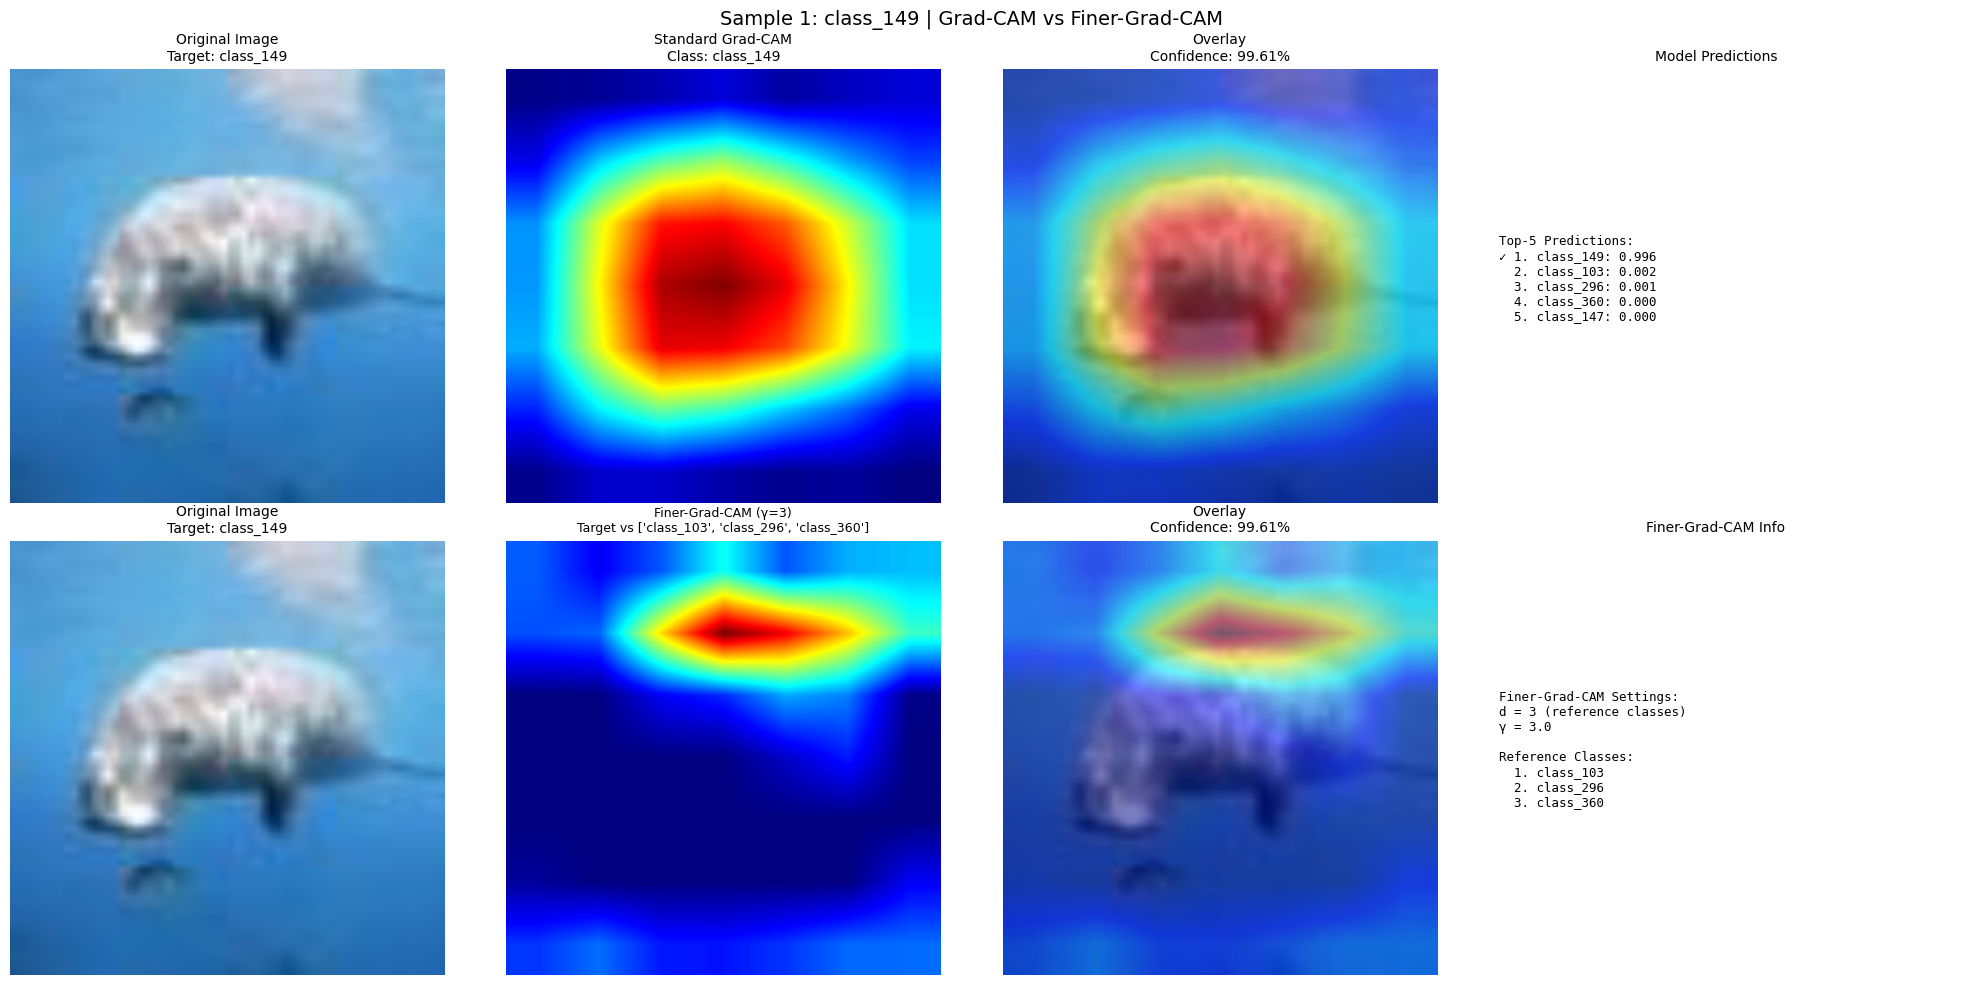


Sample 2: Dataset Index 23
Target Class: class_912 (index: 912)
Confidence: 0.9036 (90.36%)

Reference Classes (d=3):
  1. class_525 (index: 525)
  2. class_821 (index: 821)
  3. class_888 (index: 888)

Generating Standard Grad-CAM...
Generating Finer-Grad-CAM...


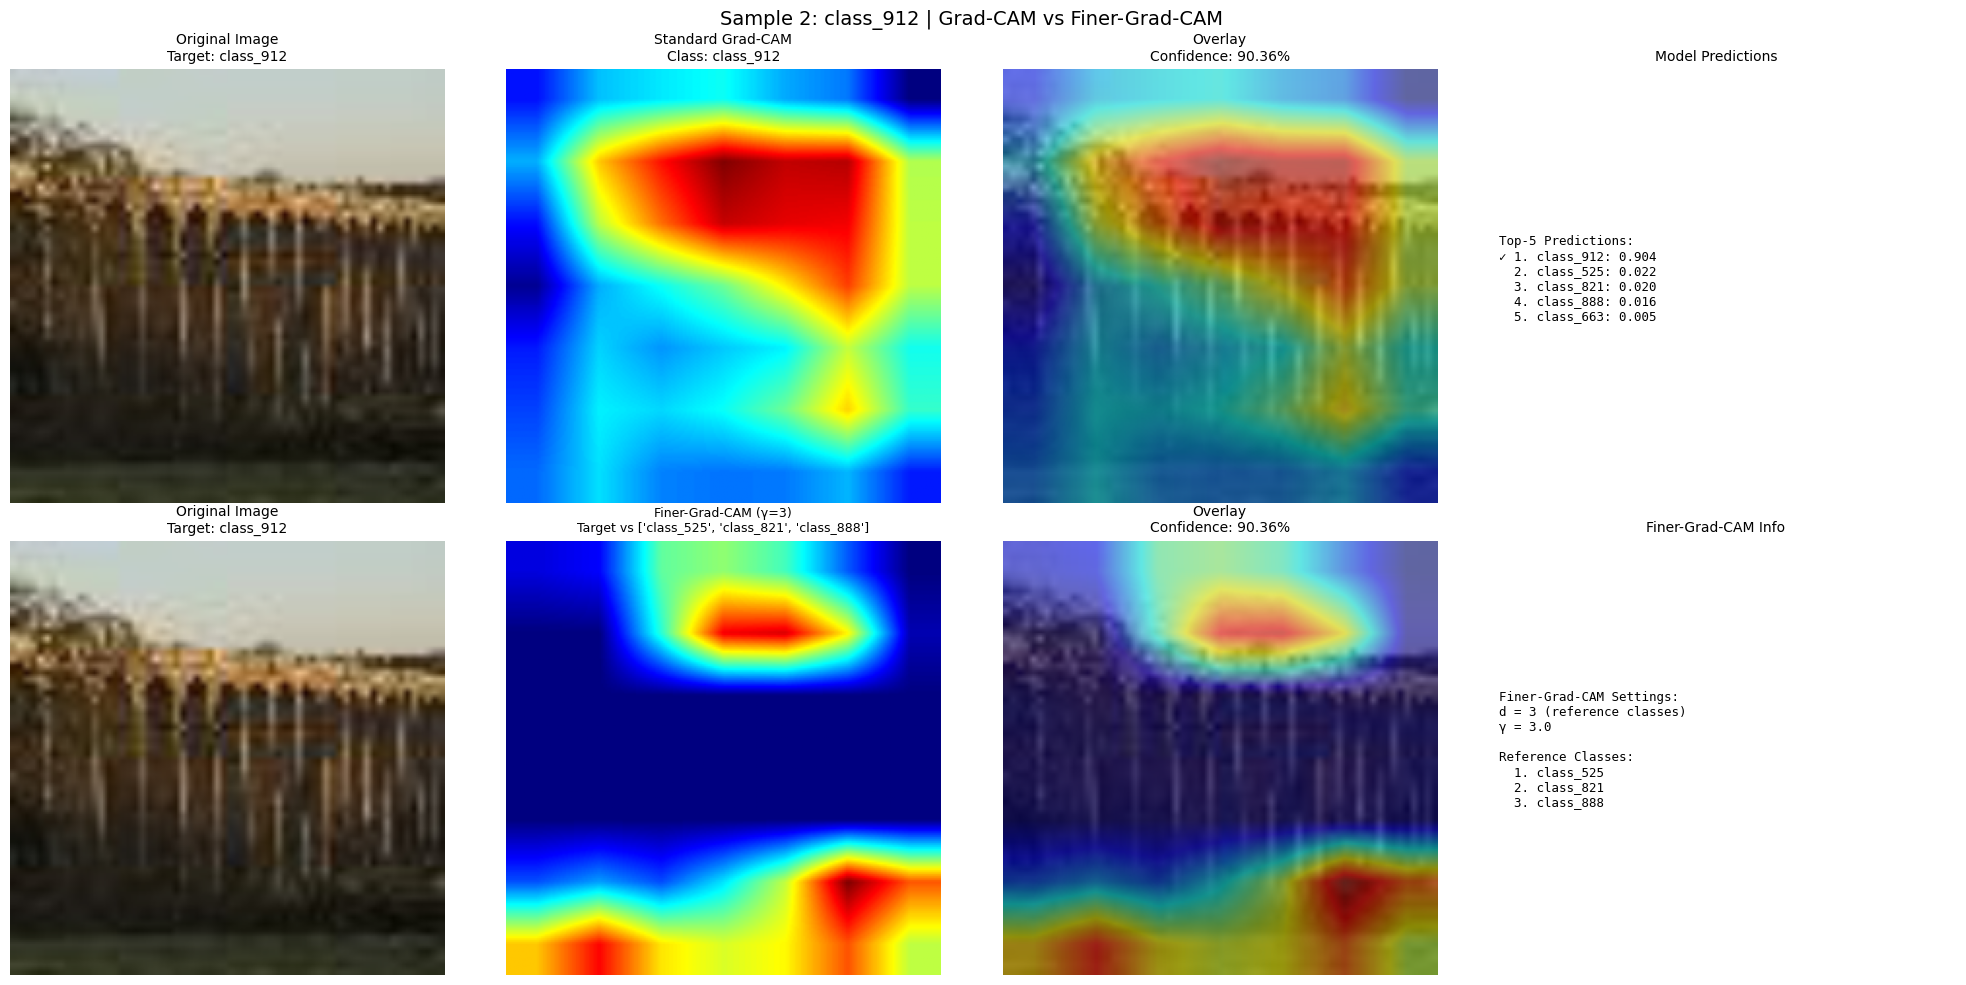


Sample 3: Dataset Index 27
Target Class: class_294 (index: 294)
Confidence: 0.9817 (98.17%)

Reference Classes (d=3):
  1. class_297 (index: 297)
  2. class_295 (index: 295)
  3. class_364 (index: 364)

Generating Standard Grad-CAM...
Generating Finer-Grad-CAM...


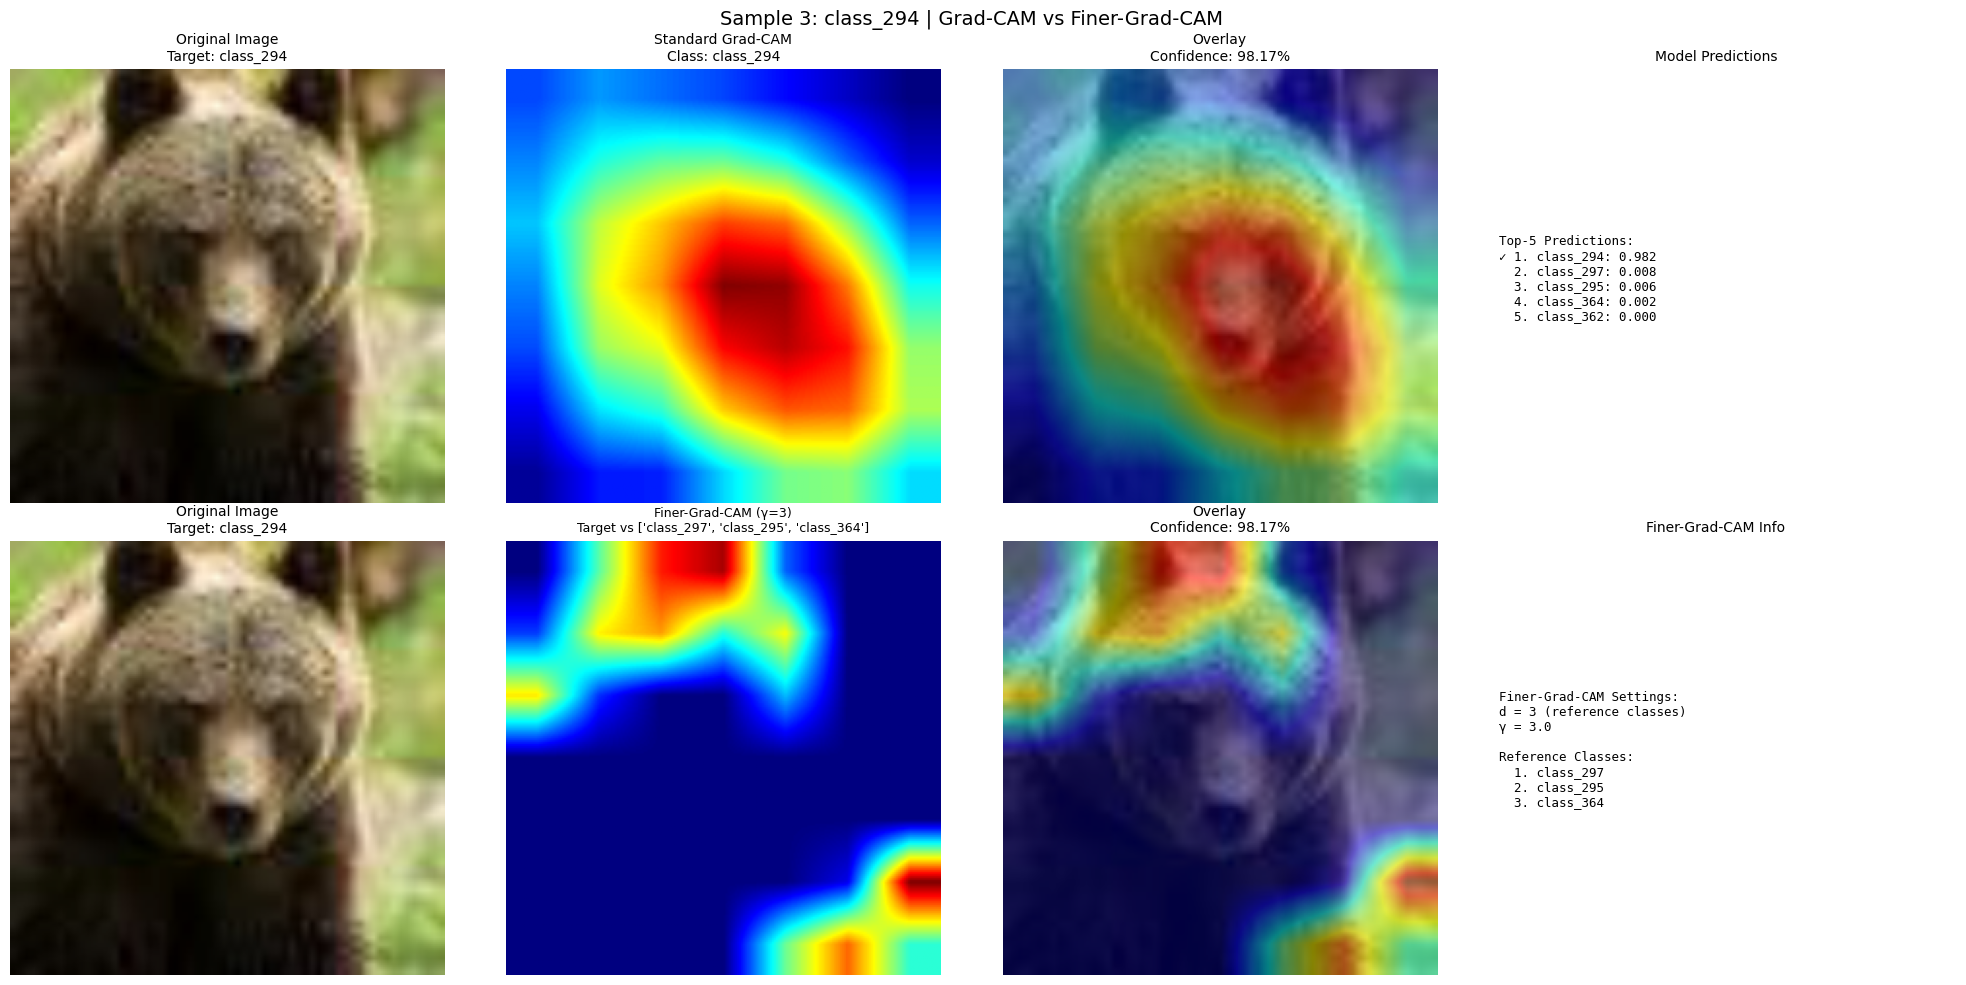


Sample 4: Dataset Index 32
Target Class: class_964 (index: 964)
Confidence: 0.9078 (90.78%)

Reference Classes (d=3):
  1. class_930 (index: 930)
  2. class_940 (index: 940)
  3. class_926 (index: 926)

Generating Standard Grad-CAM...
Generating Finer-Grad-CAM...


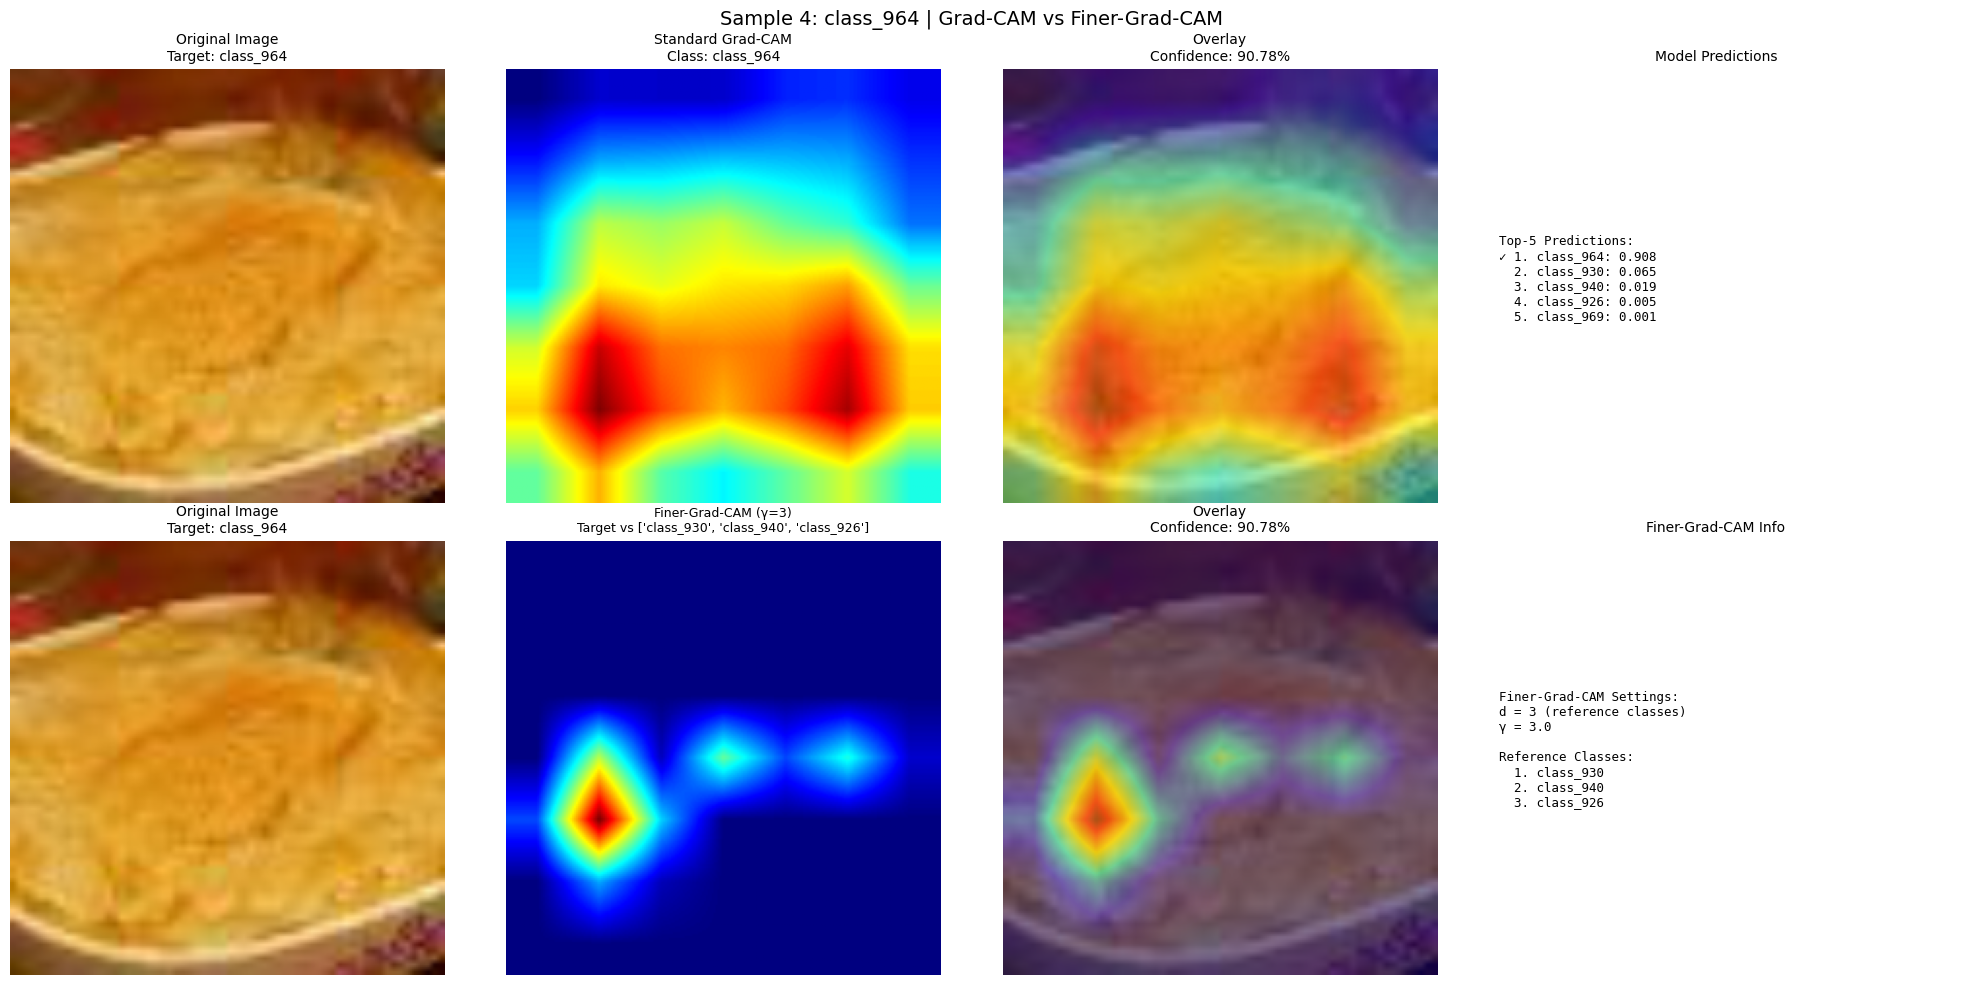


Sample 5: Dataset Index 39
Target Class: class_353 (index: 353)
Confidence: 0.9495 (94.95%)

Reference Classes (d=3):
  1. class_352 (index: 352)
  2. class_351 (index: 351)
  3. class_350 (index: 350)

Generating Standard Grad-CAM...
Generating Finer-Grad-CAM...


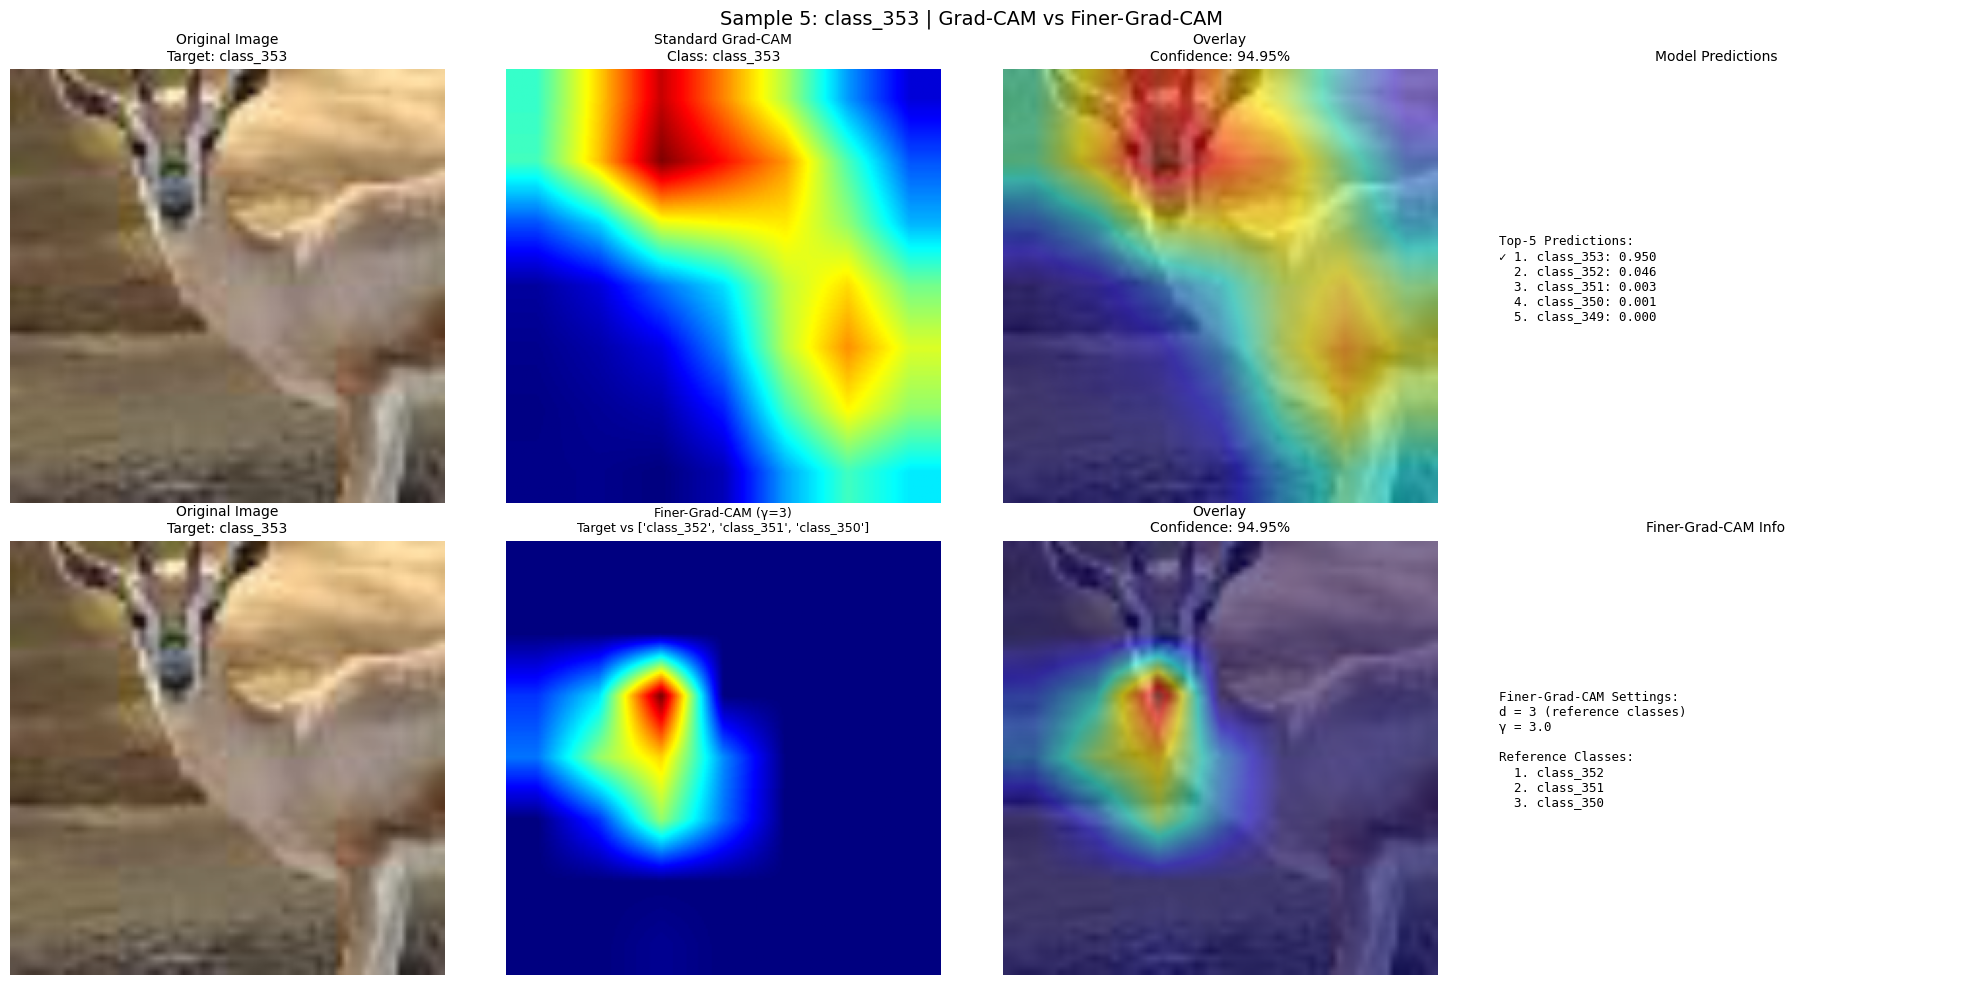


COMPLETED: Finer-Grad-CAM for ALL 5 Samples

Samples processed:
  1. Dataset Index 16 -> class_149 (conf: 99.61%)
  2. Dataset Index 23 -> class_912 (conf: 90.36%)
  3. Dataset Index 27 -> class_294 (conf: 98.17%)
  4. Dataset Index 32 -> class_964 (conf: 90.78%)
  5. Dataset Index 39 -> class_353 (conf: 94.95%)

INTERPRETATION GUIDE
Standard Grad-CAM: Shows ALL regions the model uses for the target class
Finer-Grad-CAM (γ=3, d=3): Shows ONLY regions that DISCRIMINATE
  the target class from its top-3 competing classes


In [11]:
# ============================================
# Finer-Grad-CAM Implementation - FOR YOUR 5 SAMPLES
# ============================================
# Reference: Finer-Grad-CAM: Fine-Grained Gradient-Based Visual Explanations
# Parameters: d = 3 (number of reference classes), gamma = 3 (balance factor)
# Using the exact samples from Grad-CAM visualization:
#   Sample 1: Dataset Index 16 -> class_149 (99.61%)
#   Sample 2: Dataset Index 23 -> class_912 (90.36%)
#   Sample 3: Dataset Index 27 -> class_294 (98.17%)
#   Sample 4: Dataset Index 32 -> class_964 (90.78%)
#   Sample 5: Dataset Index 39 -> class_353 (94.95%)
# ============================================

import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

class FinerGradCAM:
    """
    Finer-Grad-CAM: Contrastive visual explanations with reference classes
    
    Formula:
    alpha_k^{c,R} = (1/Z) * sum_i sum_j (dy^c/dA_ij^k - gamma * sum_{r in R} dy^r/dA_ij^k)
    L_Finer = ReLU(sum_k alpha_k^{c,R} * A^k)
    
    Parameters:
    - gamma: balance factor (default = 3.0) controls influence of reference classes
    - d: number of reference classes to use (default = 3)
    """
    def __init__(self, model, target_layer, gamma=3.0, d=3):
        self.model = model
        self.target_layer = target_layer
        self.gamma = gamma
        self.d = d
        self.activations = None
        self.gradients = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)
    
    def get_top_k_predictions(self, input_tensor, k=5):
        with torch.no_grad():
            output = self.model(input_tensor)
            probs = torch.softmax(output, dim=1)
            top_k = torch.topk(probs, k)
        return top_k.indices[0].tolist(), top_k.values[0].tolist()
    
    def get_reference_classes(self, input_tensor, target_class, d=3):
        top_classes, top_probs = self.get_top_k_predictions(input_tensor, k=10)
        reference_classes = [c for c in top_classes if c != target_class][:d]
        return reference_classes
    
    def generate(self, input_tensor, target_class, reference_classes=None):
        if reference_classes is None:
            reference_classes = self.get_reference_classes(input_tensor, target_class, self.d)
        
        output = self.model(input_tensor)
        
        # Target class gradients
        self.model.zero_grad()
        output[0, target_class].backward(retain_graph=True)
        target_gradients = self.gradients.clone()
        
        # Reference classes gradients
        reference_gradients = torch.zeros_like(target_gradients)
        for ref_class in reference_classes:
            self.model.zero_grad()
            output[0, ref_class].backward(retain_graph=True)
            reference_gradients += self.gradients.clone()
        
        if len(reference_classes) > 0:
            reference_gradients = reference_gradients / len(reference_classes)
        
        # Combine gradients
        combined_gradients = target_gradients - self.gamma * reference_gradients
        weights = combined_gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        
        self.reference_classes = reference_classes
        return cam
    
    def generate_standard_gradcam(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output[0, target_class].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        return cam
    
    def visualize(self, cam, input_image, alpha=0.5):
        cam = torch.nn.functional.interpolate(
            cam, size=(224, 224), mode='bilinear', align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        if cam.max() - cam.min() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        img = input_image.squeeze().cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        cam_heatmap = cv2.cvtColor(cam_heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = (1 - alpha) * img + alpha * cam_heatmap
        
        return img, cam_heatmap, overlay



print("="*60)
print("Initializing Finer-Grad-CAM for YOUR 5 Samples")
print(f"Parameters: d = 3, gamma = 3.0")
print("="*60)

target_layer = model.layer4[-1]
finer_gradcam = FinerGradCAM(model, target_layer, gamma=1.5, d=3)

imagenet_labels_file = "imagenet_classes.txt"
if os.path.exists(imagenet_labels_file):
    with open(imagenet_labels_file, 'r') as f:
        imagenet_class_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(imagenet_class_names)} ImageNet class names")
else:
    print("imagenet_classes.txt not found. Creating minimal mapping...")
    imagenet_class_names = [f"class_{i}" for i in range(1000)]


selected_samples = [
    {"dataset_idx": 16, "class_idx": 149, "class_name": "class_149", "confidence": 0.9961},
    {"dataset_idx": 23, "class_idx": 912, "class_name": "class_912", "confidence": 0.9036},
    {"dataset_idx": 27, "class_idx": 294, "class_name": "class_294", "confidence": 0.9817},
    {"dataset_idx": 32, "class_idx": 964, "class_name": "class_964", "confidence": 0.9078},
    {"dataset_idx": 39, "class_idx": 353, "class_name": "class_353", "confidence": 0.9495}
]

print("\n" + "="*60)
print("PROCESSING YOUR 5 SAMPLES WITH FINER-GRAD-CAM")
print("="*60)


for sample_num, sample in enumerate(selected_samples):
    dataset_idx = sample["dataset_idx"]
    target_class = sample["class_idx"]
    target_name = sample["class_name"]
    confidence = sample["confidence"]
    
    print(f"\n{'='*60}")
    print(f"Sample {sample_num + 1}: Dataset Index {dataset_idx}")
    print(f"Target Class: {target_name} (index: {target_class})")
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"{'='*60}")
    
    img, tiny_label = val_dataset[dataset_idx]
    input_tensor = img.unsqueeze(0).to(device)
    
    top_classes, top_probs = finer_gradcam.get_top_k_predictions(input_tensor, k=10)
    reference_classes = [c for c in top_classes if c != target_class][:3]
    
    print(f"\nReference Classes (d=3):")
    for i, ref_class in enumerate(reference_classes):
        ref_name = imagenet_class_names[ref_class] if ref_class < len(imagenet_class_names) else f"class_{ref_class}"
        print(f"  {i+1}. {ref_name} (index: {ref_class})")
    
    print("\nGenerating Standard Grad-CAM...")
    std_cam = finer_gradcam.generate_standard_gradcam(input_tensor, target_class)
    std_img, std_heatmap, std_overlay = finer_gradcam.visualize(std_cam, input_tensor)
    
    print("Generating Finer-Grad-CAM...")
    finer_cam = finer_gradcam.generate(input_tensor, target_class, reference_classes)
    finer_img, finer_heatmap, finer_overlay = finer_gradcam.visualize(finer_cam, input_tensor)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    axes[0, 0].imshow(std_img)
    axes[0, 0].set_title(f'Original Image\nTarget: {target_name}', fontsize=10)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(std_heatmap)
    axes[0, 1].set_title(f'Standard Grad-CAM\nClass: {target_name}', fontsize=10)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(std_overlay)
    axes[0, 2].set_title(f'Overlay\nConfidence: {confidence:.2%}', fontsize=10)
    axes[0, 2].axis('off')
    
    axes[0, 3].axis('off')
    top5_text = "Top-5 Predictions:\n"
    for i in range(5):
        if i < len(top_classes):
            idx = top_classes[i]
            name = imagenet_class_names[idx] if idx < len(imagenet_class_names) else f"class_{idx}"
            prob = top_probs[i]
            marker = "✓" if idx == target_class else " "
            top5_text += f"{marker} {i+1}. {name}: {prob:.3f}\n"
    axes[0, 3].text(0.05, 0.5, top5_text, fontsize=9, verticalalignment='center', family='monospace')
    axes[0, 3].set_title('Model Predictions', fontsize=10)
    
    axes[1, 0].imshow(finer_img)
    axes[1, 0].set_title(f'Original Image\nTarget: {target_name}', fontsize=10)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(finer_heatmap)
    ref_names = []
    for r in reference_classes:
        name = imagenet_class_names[r] if r < len(imagenet_class_names) else f"class_{r}"
        ref_names.append(name.split(',')[0][:20])
    axes[1, 1].set_title(f'Finer-Grad-CAM (γ=3)\nTarget vs {ref_names}', fontsize=9)
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(finer_overlay)
    axes[1, 2].set_title(f'Overlay\nConfidence: {confidence:.2%}', fontsize=10)
    axes[1, 2].axis('off')
    
    axes[1, 3].axis('off')
    ref_text = "Finer-Grad-CAM Settings:\n"
    ref_text += f"d = 3 (reference classes)\n"
    ref_text += f"γ = 3.0\n\n"
    ref_text += "Reference Classes:\n"
    for i, (r, name) in enumerate(zip(reference_classes, ref_names)):
        ref_text += f"  {i+1}. {name}\n"
    axes[1, 3].text(0.05, 0.5, ref_text, fontsize=9, verticalalignment='center', family='monospace')
    axes[1, 3].set_title('Finer-Grad-CAM Info', fontsize=10)
    
    plt.suptitle(f'Sample {sample_num+1}: {target_name} | Grad-CAM vs Finer-Grad-CAM', fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("COMPLETED: Finer-Grad-CAM for ALL 5 Samples")
print("="*60)
print("\nSamples processed:")
for i, sample in enumerate(selected_samples):
    print(f"  {i+1}. Dataset Index {sample['dataset_idx']} -> {sample['class_name']} (conf: {sample['confidence']:.2%})")
print("\n" + "="*60)
print("INTERPRETATION GUIDE")
print("="*60)
print("Standard Grad-CAM: Shows ALL regions the model uses for the target class")
print("Finer-Grad-CAM (γ=3, d=3): Shows ONLY regions that DISCRIMINATE")
print("  the target class from its top-3 competing classes")
print("="*60)